In [1]:
pip install --upgrade jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import numpy as np

In [4]:
df = pd.read_csv(r'C:\Users\paulo\Desktop\pythonAnalise\analise\projeto4\bank-full.csv', sep=r',|;', engine='python')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Tratamento e Criação de Features (Transform)
A base parece não ter nulos, mas precisamos preparar os dados para os gráficos.
   
    1.Conversão do Target: A coluna Target tem textos ("yes" e "no"). Crie uma nova coluna chamada Target_Int mapeando "yes" para 1 e "no" para 0. Isso vai nos permitir calcular a taxa de conversão como uma média matemática!

2.	Faixa Etária: Temos a idade exata (age), mas o marketing quer ver grupos. Crie uma coluna age_group classificando assim:
   
    o	Menor de 30 anos -> "Jovem"
    
    o	Entre 30 e 50 anos -> "Adulto"
   
    o	Maior que 50 anos -> "Sênior"


In [7]:
df ['Target_Int'] = df ['Target'].apply(lambda target: '1' if target in ['yes'] else '0') # convertendo os target e criando uma nova coluna para os valores

In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target,Target_Int
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [11]:
df ['Target_Int'] = df ['Target_Int'].astype(int) # convertendo os números para inteiros

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         45211 non-null  int64 
 1   job         45211 non-null  object
 2   marital     45211 non-null  object
 3   education   45211 non-null  object
 4   default     45211 non-null  object
 5   balance     45211 non-null  int64 
 6   housing     45211 non-null  object
 7   loan        45211 non-null  object
 8   contact     45211 non-null  object
 9   day         45211 non-null  int64 
 10  month       45211 non-null  object
 11  duration    45211 non-null  int64 
 12  campaign    45211 non-null  int64 
 13  pdays       45211 non-null  int64 
 14  previous    45211 non-null  int64 
 15  poutcome    45211 non-null  object
 16  Target      45211 non-null  object
 17  Target_Int  45211 non-null  int64 
dtypes: int64(8), object(10)
memory usage: 6.2+ MB


In [13]:
# criando as condições para que exista uma coluna informando o grupo dos indivíduos pela idade
condicoes_idade = [
                df['age'] < 30,
                (df['age'] >= 30) & (df['age'] <= 50),
                (df['age'] > 50)
]

escolhas_grupo = ['Jovem', 'Adulto', 'Sênior']


In [14]:
df ['Grupo'] = np.select(condicoes_idade, escolhas_grupo, default= '999') # aplicando os valores na nova coluna

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         45211 non-null  int64 
 1   job         45211 non-null  object
 2   marital     45211 non-null  object
 3   education   45211 non-null  object
 4   default     45211 non-null  object
 5   balance     45211 non-null  int64 
 6   housing     45211 non-null  object
 7   loan        45211 non-null  object
 8   contact     45211 non-null  object
 9   day         45211 non-null  int64 
 10  month       45211 non-null  object
 11  duration    45211 non-null  int64 
 12  campaign    45211 non-null  int64 
 13  pdays       45211 non-null  int64 
 14  previous    45211 non-null  int64 
 15  poutcome    45211 non-null  object
 16  Target      45211 non-null  object
 17  Target_Int  45211 non-null  int64 
 18  Grupo       45211 non-null  object
dtypes: int64(8), object(11)
memory usage: 6.6+ MB


Análise Visual (Data Visualization)

Aqui entra o show! Use o seaborn (sns) ou o próprio pandas para criar 3 gráficos:

1.	O Perfil (Gráfico de Barras): Qual é a profissão (job) mais comum dos clientes que contatamos?


2.	O Dinheiro (Histograma ou Boxplot): Mostre a distribuição do saldo bancário (balance) dos clientes.

    o	Desafio: Como temos gente muito rica, o gráfico pode ficar espremido. Filtre para plotar apenas clientes com saldo entre 0 e 20.000 para a visualização ficar melhor.

3.	A Conversão (Gráfico de Barras com Média): Qual estado civil (marital) tem a maior taxa de conversão (ou seja, a maior média na coluna Target_Int que você criou)?



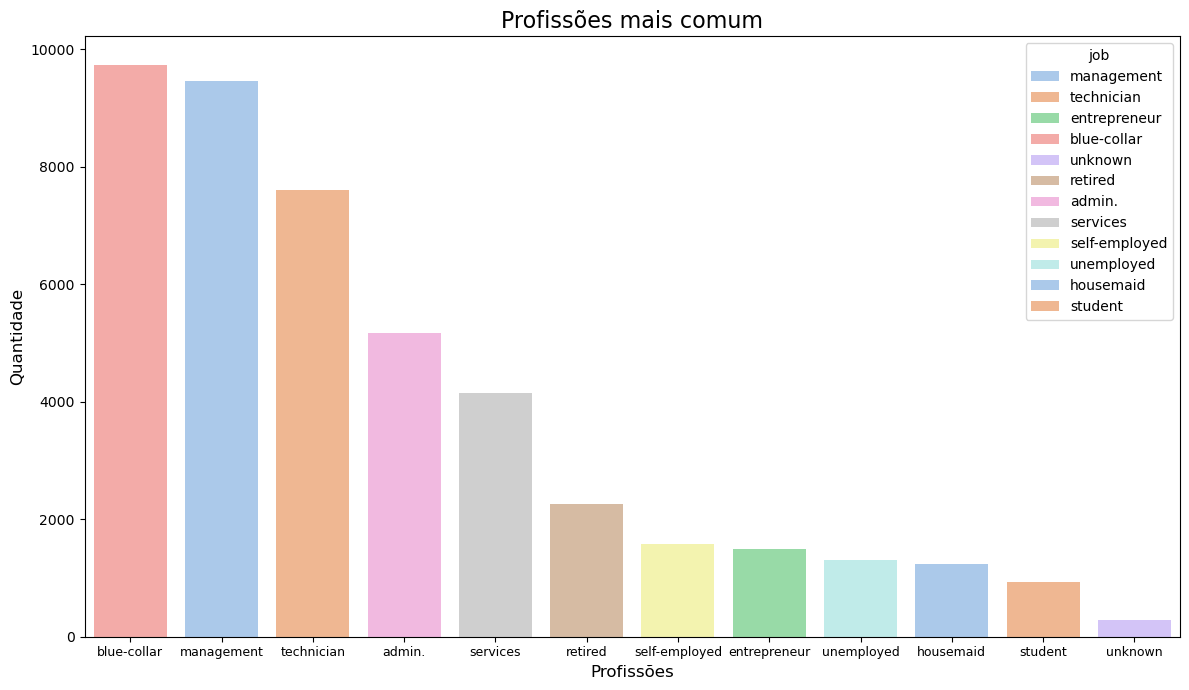

In [16]:
# Qual é a profissão (job) mais comum dos clientes que contatamos?

plt.figure(figsize=(12, 7))

grafico = sns.countplot(data=df, x='job', order=df['job'].value_counts().index, hue= 'job', palette = "pastel", legend= True) 




plt.title('Profissões mais comum', fontsize = 16)
plt.xlabel('Profissões', fontsize = 12)
plt.ylabel('Quantidade', fontsize = 12)
plt.xticks(fontsize=9)


sns.color_palette("pastel", len('job'))

plt.tight_layout()
plt.show()

imagem = grafico.get_figure()
imagem.savefig('Grafico_Profissoes.png') 

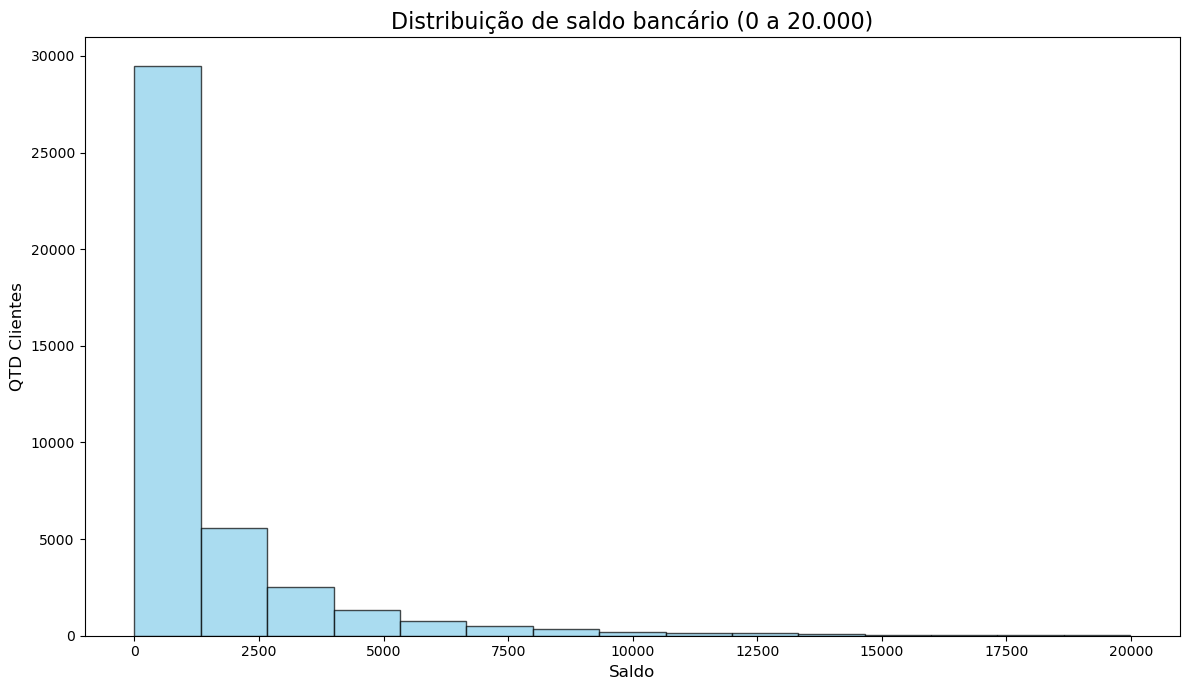

In [17]:
# Mostre a distribuição do saldo bancário (balance) dos clientes

df_filtrado = df[(df['balance'] >= 0) & (df['balance'] <= 20000)]


grafico2 = plt.figure(figsize=(12, 7))
plt.hist(df_filtrado['balance'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)


plt.title('Distribuição de saldo bancário (0 a 20.000)', fontsize = 16)
plt.xlabel('Saldo', fontsize = 12)
plt.ylabel('QTD Clientes', fontsize = 12)

plt.tight_layout()
plt.show()

imagem2 = grafico2.get_figure()
imagem2.savefig('Grafico_Distribuicao_Saldo.png') 



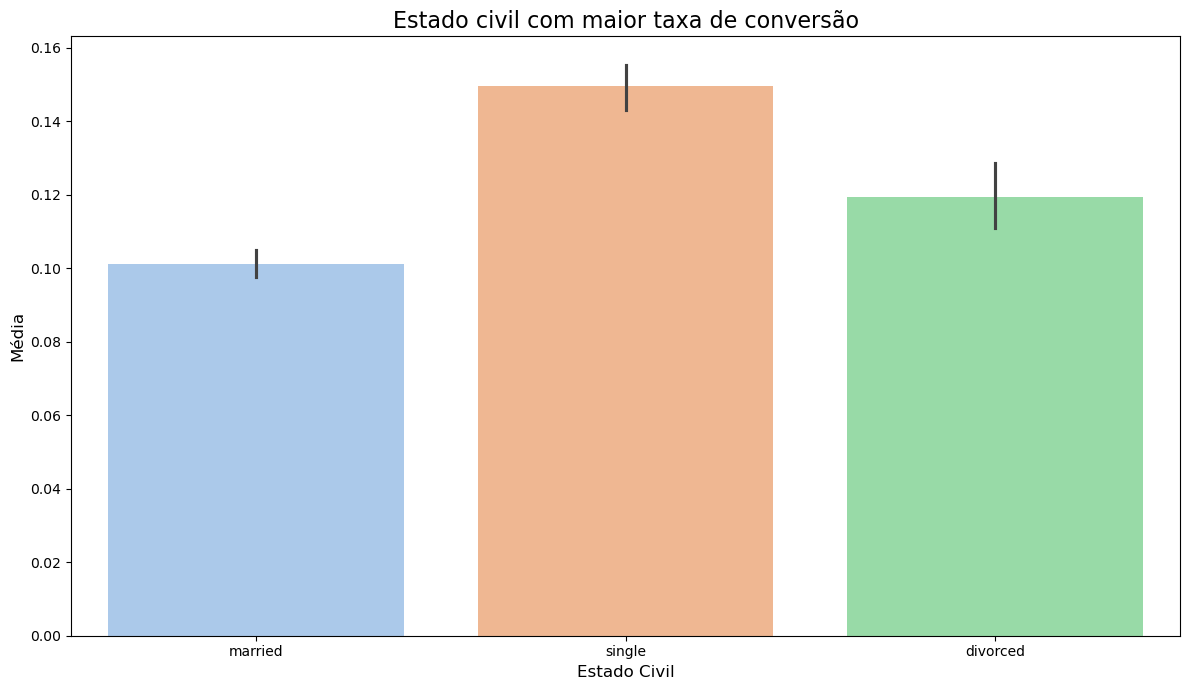

In [18]:
# Qual estado civil (marital) tem a maior taxa de conversão (ou seja, a maior média na coluna Target_Int que você criou)?

plt.figure(figsize=(12, 7))

grafico3 = sns.barplot(data=df, x='marital', y= 'Target_Int', hue='marital', palette = "pastel", legend=False)

plt.title('Estado civil com maior taxa de conversão', fontsize = 16)
plt.ylabel('Média', fontsize = 12)
plt.xlabel('Estado Civil', fontsize = 12)

plt.tight_layout()
plt.show()


imagem3 = grafico3.get_figure()
imagem3.savefig('Grafico_Estado_Civil.png') 


In [20]:
# pegando a coluna "grupos" e alocando ela para a segunda posição
cols = df.columns.tolist()

cols.insert(1, cols.pop(18))

df= df[cols]

df

,age,Grupo,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target,Target_Int
0,58,Sênior,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,Adulto,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,Adulto,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,Adulto,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,Adulto,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,Sênior,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1
45207,71,Sênior,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1
45208,72,Sênior,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1
45209,57,Sênior,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0


In [27]:
df.to_csv('banco_tratado.csv', index=False, sep=';', encoding='utf-8-sig')